# 1st Hidden Layer — Evaluate Little-Perturbation Checkpoints

In the 1st-layer perturbation sweeps, models trained with a *little*
perturbation tend to score better at their matched evaluation level. This
notebook isolates that effect: for each perturbation type it loads checkpoints
**trained at several small perturbation levels** and evaluates each one across
the **entire** perturbation sweep (eval-on-checkpoint), rather than training a
fresh model per level.

Each perturbation is evaluated twice — once for the **no-delay** model and once
for the **delay** model. Every plot overlays the checkpoints trained at several
levels together with the no-perturbation reference:

- **Relocation** — per-spike random relocation; checkpoints `f = 0.2, 0.4, 0.6`.
- **Jitter** — per-spike Gaussian jitter; checkpoints `sigma = 3, 5, 10`.
- **Shift** — per-neuron Gaussian shift; checkpoints `sigma = 3, 5, 10`.
- **Deletion** — per-spike deletion; checkpoints `p_d = 0.1, 0.2, 0.4`.

Evaluations cover the **whole / part / norm** SHD variants. The final sections
plot the eval-on-checkpoint sweeps (read from `log_eval_on_perturbatedModel/`)
against the **no-perturbation** model (a checkpoint trained on the clean dataset
and evaluated across the whole sweep), read from each perturbation's
`1stLayer_log/` folder and, for relocation, from `shd/1stLayer_log/`.

In [1]:
# Setup: reuse the 2nd-layer training modules (model classes, data pipeline
# and evaluation routines) so the evaluation matches the original sweeps.
import sys
import json
from pathlib import Path

import numpy as np
import torch

BASE_DIR = Path.cwd()
assert (BASE_DIR / "jitter").is_dir(), (
    "Run this notebook from my_project/code/perturbation/ so the "
    "jitter / shift / deletion packages are importable."
)

for sub in ("jitter", "shift", "deletion"):
    sub_path = str((BASE_DIR / sub).resolve())
    if sub_path not in sys.path:
        sys.path.append(sub_path)

# Dataset variants to evaluate (matches result_visualization_2ndLayer.ipynb).
EVAL_DATASETS = ("whole", "part", "norm")

# Destination for the eval-on-checkpoint sweep results.
EVAL_LOG_DIR = Path("log_eval_on_perturbatedModel")
EVAL_LOG_DIR.mkdir(parents=True, exist_ok=True)
print(f"Eval results dir: {EVAL_LOG_DIR.resolve()}")

Eval results dir: D:\IC_2025\IRP\workspace\my_project\exp_fixed_weight_perturbation\result_visualization\PAT_results\perturbation\log_eval_on_perturbatedModel


## 4. Comparison: checkpoints trained at several perturbation levels

The four perturbation types are combined into a single figure with 8 panels:
**2 rows** (no-delay / with-delay) &times; **4 columns** (relocation / jitter /
shift / deletion). Each panel overlays, on a single axis:

- **Solid lines** — a checkpoint trained at a given perturbation level, then
  evaluated across the whole sweep (read from `log_eval_on_perturbatedModel/`).
  One solid curve per training level.
- **Dashed, &#10005;** — the **no-perturbation** model: a single checkpoint
  trained on the clean dataset and evaluated across the whole sweep. For jitter
  and shift this is the
  `{pert}/1stLayer_log/{pert}_{ds}_{delay}_{pert}_sweep_results.json` file (the
  first-layer `*_train.py` scripts train one clean model, then sweep the
  perturbation at evaluation time); for deletion it is the
  `deletion/1stLayer_log/deletion_{ds}_{delay}_evalOnly_deletion_sweep_results.json`
  file; for relocation it is the
  `shd/1stLayer_log/shd_{ds}_{delay}_hidden_perturbation_results.json` file.

Two encodings share each axis: **hue** = dataset (Whole / Part / Norm) and
**colour depth** = the checkpoint's training level. Within one dataset the
curves keep the same hue; the no-perturbation baseline is the lightest shade and
each higher training level is drawn in a progressively deeper shade of that hue.
Relocation overlays checkpoints trained at `f = 0.2, 0.4, 0.6`; jitter and shift
overlay `sigma = 3, 5, 10`; deletion overlays `p_d = 0.1, 0.2, 0.4`. The level
legend (top row) and dataset legend (top-left panel) are shown once and apply to
every panel.

Note that the relocation baseline is swept on a finer grid (`f` in steps of 0.1)
than its checkpoints (steps of 0.2), so the dashed baseline curve in that column
carries more points than the solid ones.

In [2]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.colors as mcolors
import matplotlib as mpl

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "legend.fontsize": 9,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 150,
})

COLORS = {"Whole": "#1f77b4", "Part": "#2ca02c", "Norm": "#d62728"}
DS_LABEL = {"whole": "Whole", "part": "Part", "norm": "Norm"}


def shade(base_color, frac):
    """Return a lighter/darker variant of ``base_color`` keeping its hue.

    ``frac`` in ``[0, 1]`` maps the lightest variant (0, blended toward white)
    to the darkest variant (1, blended toward black), so higher perturbation
    levels can be drawn in a deeper shade of the same colour.
    """
    rgb = np.array(mcolors.to_rgb(base_color))
    lightest = rgb + (1.0 - rgb) * 0.55
    darkest = rgb * 0.45
    return tuple(lightest + (darkest - lightest) * frac)


def _depth_fracs(num_levels):
    """Depth positions for the baseline + each level (light -> dark).

    Index 0 is the no-perturbation baseline (lightest); the ``num_levels``
    checkpoint curves then deepen as the training level increases.
    """
    total = num_levels + 1
    return [j / (total - 1) for j in range(total)]


def load_sweep(path, key_type=int):
    """Load a sweep JSON -> (levels, means_pct, stds_pct)."""
    with open(path) as fh:
        raw = json.load(fh)
    levels = sorted(key_type(k) for k in raw)
    means = np.array([raw[str(lvl)]["mean"] for lvl in levels]) * 100
    stds = np.array([raw[str(lvl)]["std"] for lvl in levels]) * 100
    return levels, means, stds


def plot_multilevel(ax, level_series, baseline_paths, key_type, xlabel, title,
                    xlim, level_title, show_level_legend=True, show_ds_legend=True):
    """Overlay eval-on-checkpoint sweeps for several training levels onto ``ax``.

    Dataset is encoded by colour (hue); the checkpoint's *training* perturbation
    level is encoded by the depth of that colour — the no-perturbation baseline
    is the lightest shade (dashed) and each deeper shade is a checkpoint trained
    at a higher level. ``level_series`` is a list of
    ``(level_label, paths_by_dataset)`` tuples in ascending level order.
    """
    fracs = _depth_fracs(len(level_series))
    for ds in EVAL_DATASETS:
        base = COLORS[DS_LABEL[ds]]
        bx, bmeans, _ = load_sweep(baseline_paths[ds], key_type)
        ax.plot(bx, bmeans, linestyle="--", marker="x", color=shade(base, fracs[0]),
                markersize=6, linewidth=1.6)
        for idx, (_, paths) in enumerate(level_series):
            x, means, _ = load_sweep(paths[ds], key_type)
            ax.plot(x, means, linestyle="-", marker="o", color=shade(base, fracs[idx + 1]),
                    markersize=4, linewidth=1.6)

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Test Accuracy (%)")
    ax.set_xlim(*xlim)
    ax.set_ylim(0, None)
    ax.grid(True, linestyle=":", linewidth=0.7, alpha=0.7)

    # Depth legend: neutral grey ramp conveying the light->dark level ordering.
    grey = "#7f7f7f"
    level_handles = [
        mlines.Line2D([], [], color=shade(grey, fracs[0]), marker="x",
                      linestyle="--", markersize=6, linewidth=1.6,
                      label="no perturbation")
    ]
    level_handles += [
        mlines.Line2D([], [], color=shade(grey, fracs[idx + 1]), marker="o",
                      linestyle="-", markersize=4, linewidth=1.6,
                      label=f"ckpt {label}")
        for idx, (label, _) in enumerate(level_series)
    ]
    ds_handles = [
        mlines.Line2D([], [], color=COLORS[DS_LABEL[ds]], linewidth=2.5,
                      label=DS_LABEL[ds])
        for ds in EVAL_DATASETS
    ]

    if show_level_legend:
        level_legend = ax.legend(handles=level_handles, loc="upper right",
                                 framealpha=0.9, title=level_title, fontsize=8)
        ax.add_artist(level_legend)
    if show_ds_legend:
        ax.legend(handles=ds_handles, loc="lower left", framealpha=0.9,
                  title="Dataset", fontsize=8)

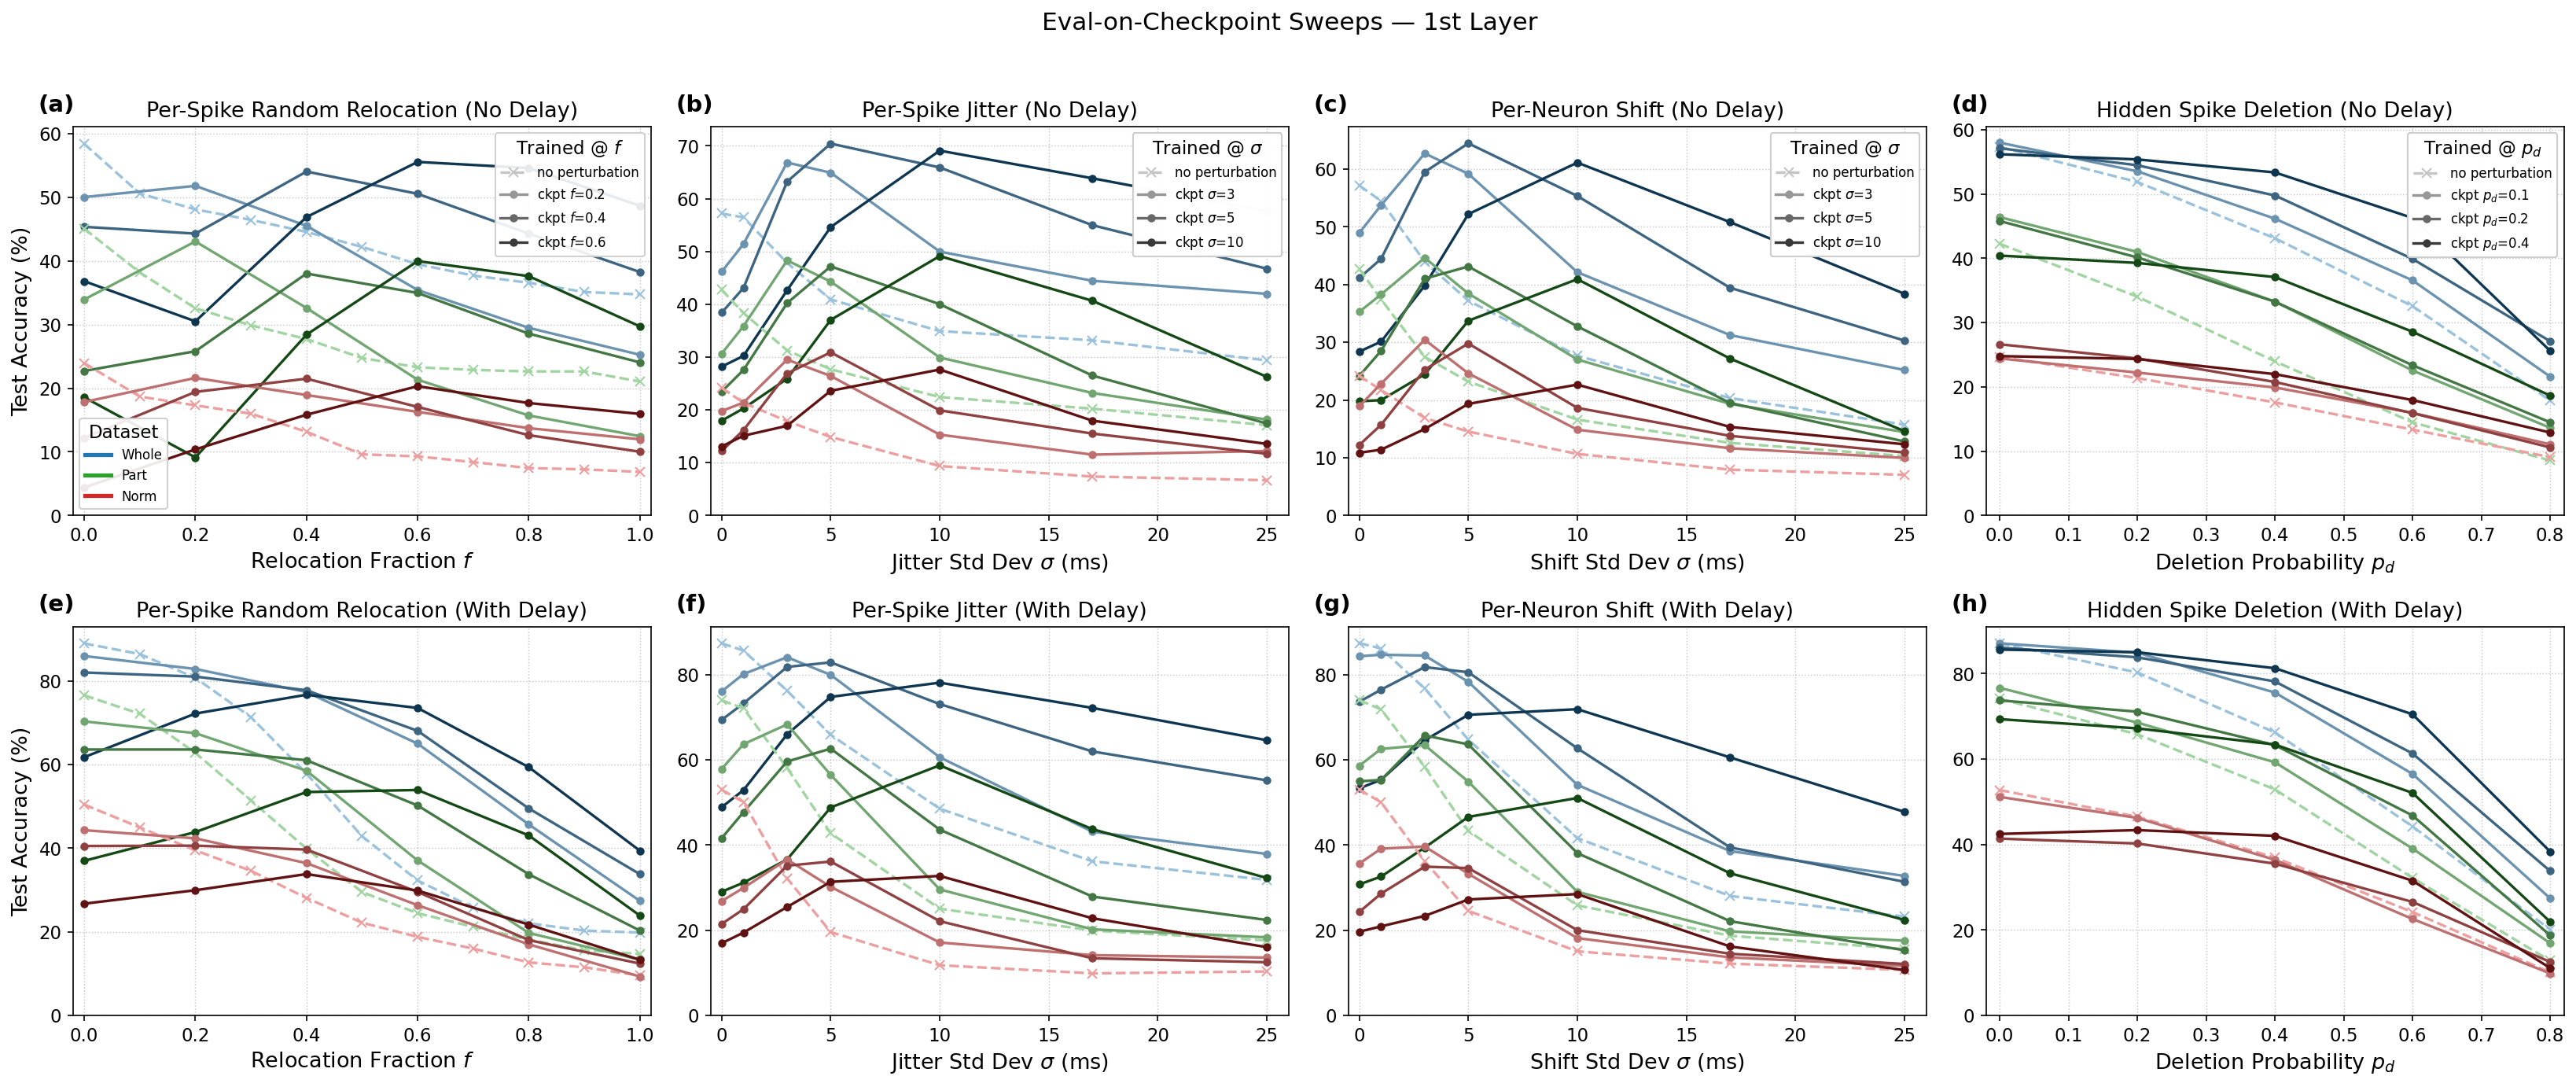

In [3]:
# Combined comparison figure: 2 rows (no-delay / delay) x 4 columns
# (relocation / jitter / shift / deletion). Checkpoints trained at each
# perturbation level to overlay per column.
RELOCATION_CKPT_FS = [0.2, 0.4, 0.6]
JITTER_CKPT_SIGMAS = [3, 5, 10]
SHIFT_CKPT_SIGMAS = [3, 5, 10]
DELETION_CKPT_PDS = [0.1, 0.2, 0.4]

DELAY_LABEL = {"nodelay": "No Delay", "delay": "With Delay"}


def _pd_token(p_d):
    """File token for a deletion probability, e.g. 0.2 -> 'pd02'."""
    return f"pd{int(round(p_d * 10)):02d}"


def _relocation_config(delay_tag):
    """Build the per-spike random relocation panel config for one delay mode.

    The relocation sweeps are the Phase 2 realistic SHD runs: the baseline is the
    clean checkpoint's hidden-perturbation sweep in ``shd/1stLayer_log/``.
    """
    level_series = [
        (rf"$f$={f}", {
            ds: EVAL_LOG_DIR / f"shd_1stLayer_{ds}_{delay_tag}_evalon_f{f}.json"
            for ds in EVAL_DATASETS
        })
        for f in RELOCATION_CKPT_FS
    ]
    baseline_paths = {
        ds: Path("shd/1stLayer_log")
        / f"shd_{ds}_{delay_tag}_hidden_perturbation_results.json"
        for ds in EVAL_DATASETS
    }
    return dict(
        level_series=level_series, baseline_paths=baseline_paths, key_type=float,
        xlabel=r"Relocation Fraction $f$", xlim=(-0.02, 1.02),
        level_title=r"Trained @ $f$", name="Per-Spike Random Relocation",
    )


def _jitter_config(delay_tag):
    """Build the jitter panel config for one delay mode."""
    level_series = [
        (rf"$\sigma$={sigma}", {
            ds: EVAL_LOG_DIR
            / f"jitter_1stLayer_{ds}_{delay_tag}_evalon_sigma{sigma}.json"
            for ds in EVAL_DATASETS
        })
        for sigma in JITTER_CKPT_SIGMAS
    ]
    baseline_paths = {
        ds: Path("jitter/1stLayer_log")
        / f"jitter_{ds}_{delay_tag}_jitter_sweep_results.json"
        for ds in EVAL_DATASETS
    }
    return dict(
        level_series=level_series, baseline_paths=baseline_paths, key_type=int,
        xlabel=r"Jitter Std Dev $\sigma$ (ms)", xlim=(-0.5, 26),
        level_title=r"Trained @ $\sigma$", name="Per-Spike Jitter",
    )


def _shift_config(delay_tag):
    """Build the shift panel config for one delay mode."""
    level_series = [
        (rf"$\sigma$={sigma}", {
            ds: EVAL_LOG_DIR
            / f"shift_1stLayer_{ds}_{delay_tag}_evalon_sigma{sigma}.json"
            for ds in EVAL_DATASETS
        })
        for sigma in SHIFT_CKPT_SIGMAS
    ]
    baseline_paths = {
        ds: Path("shift/1stLayer_log")
        / f"shift_{ds}_{delay_tag}_shift_sweep_results.json"
        for ds in EVAL_DATASETS
    }
    return dict(
        level_series=level_series, baseline_paths=baseline_paths, key_type=int,
        xlabel=r"Shift Std Dev $\sigma$ (ms)", xlim=(-0.5, 26),
        level_title=r"Trained @ $\sigma$", name="Per-Neuron Shift",
    )


def _deletion_config(delay_tag):
    """Build the deletion panel config for one delay mode."""
    level_series = [
        (rf"$p_d$={p_d}", {
            ds: EVAL_LOG_DIR
            / f"deletion_1stLayer_{ds}_{delay_tag}_evalon_{_pd_token(p_d)}.json"
            for ds in EVAL_DATASETS
        })
        for p_d in DELETION_CKPT_PDS
    ]
    baseline_paths = {
        ds: Path("deletion/1stLayer_log")
        / f"deletion_{ds}_{delay_tag}_evalOnly_deletion_sweep_results.json"
        for ds in EVAL_DATASETS
    }
    return dict(
        level_series=level_series, baseline_paths=baseline_paths, key_type=float,
        xlabel=r"Deletion Probability $p_d$", xlim=(-0.02, 0.82),
        level_title=r"Trained @ $p_d$", name="Hidden Spike Deletion",
    )


# Column order: relocation, jitter, shift, deletion. Row order: no-delay, delay.
COLUMN_BUILDERS = (
    _relocation_config, _jitter_config, _shift_config, _deletion_config,
)
ROW_DELAY_TAGS = ("nodelay", "delay")
NUM_COLUMNS = len(COLUMN_BUILDERS)

fig, axes = plt.subplots(2, NUM_COLUMNS, figsize=(22, 9))

for row, delay_tag in enumerate(ROW_DELAY_TAGS):
    for col, build_config in enumerate(COLUMN_BUILDERS):
        cfg = build_config(delay_tag)
        ax = axes[row, col]
        plot_multilevel(
            ax, cfg["level_series"], cfg["baseline_paths"], cfg["key_type"],
            xlabel=cfg["xlabel"],
            title=f"{cfg['name']} ({DELAY_LABEL[delay_tag]})",
            xlim=cfg["xlim"], level_title=cfg["level_title"],
            show_level_legend=(row == 0), show_ds_legend=(row == 0 and col == 0),
        )
        if col > 0:
            ax.set_ylabel("")
        panel_label = chr(ord("a") + row * NUM_COLUMNS + col)
        ax.text(-0.06, 1.04, f"({panel_label})", transform=ax.transAxes,
                fontsize=14, fontweight="bold")

fig.suptitle("Eval-on-Checkpoint Sweeps — 1st Layer", y=1.02, fontsize=15)
fig.tight_layout()
plt.show()

## 5. Eval-on-Checkpoint Heatmaps

The same eval-on-checkpoint sweeps from Section 4 are shown again as
heatmaps, one figure per dataset variant (Whole / Part / Norm). Within each
figure the panels are arranged exactly like Section 4 — **2 rows** (no-delay
/ with-delay) &times; **4 columns** (relocation / jitter / shift / deletion) —
but each panel is now a grid instead of a line plot:

- **Rows** — the perturbation level the checkpoint was **trained** at
  (`no perturbation` baseline, then each checkpoint level in ascending order).
- **Columns** — the perturbation level the model is **evaluated** at, i.e.
  the full sweep.
- **Cell colour / annotation** — test accuracy (%) at that
  (train level, eval level) pair. Darker cells mean higher accuracy; every
  cell is also annotated with its value. All panels in this section (and
  across all three dataset figures) share the same colour scale (0-100%), so
  colour is directly comparable across panels.

A heatmap needs one shared column axis, so each panel is restricted to the eval
levels every row has in common. This is a no-op for jitter, shift and deletion,
whose baseline and checkpoint sweeps use identical grids; for relocation it drops
the baseline-only odd multiples of 0.1, keeping `f = 0.0, 0.2, ..., 1.0`.

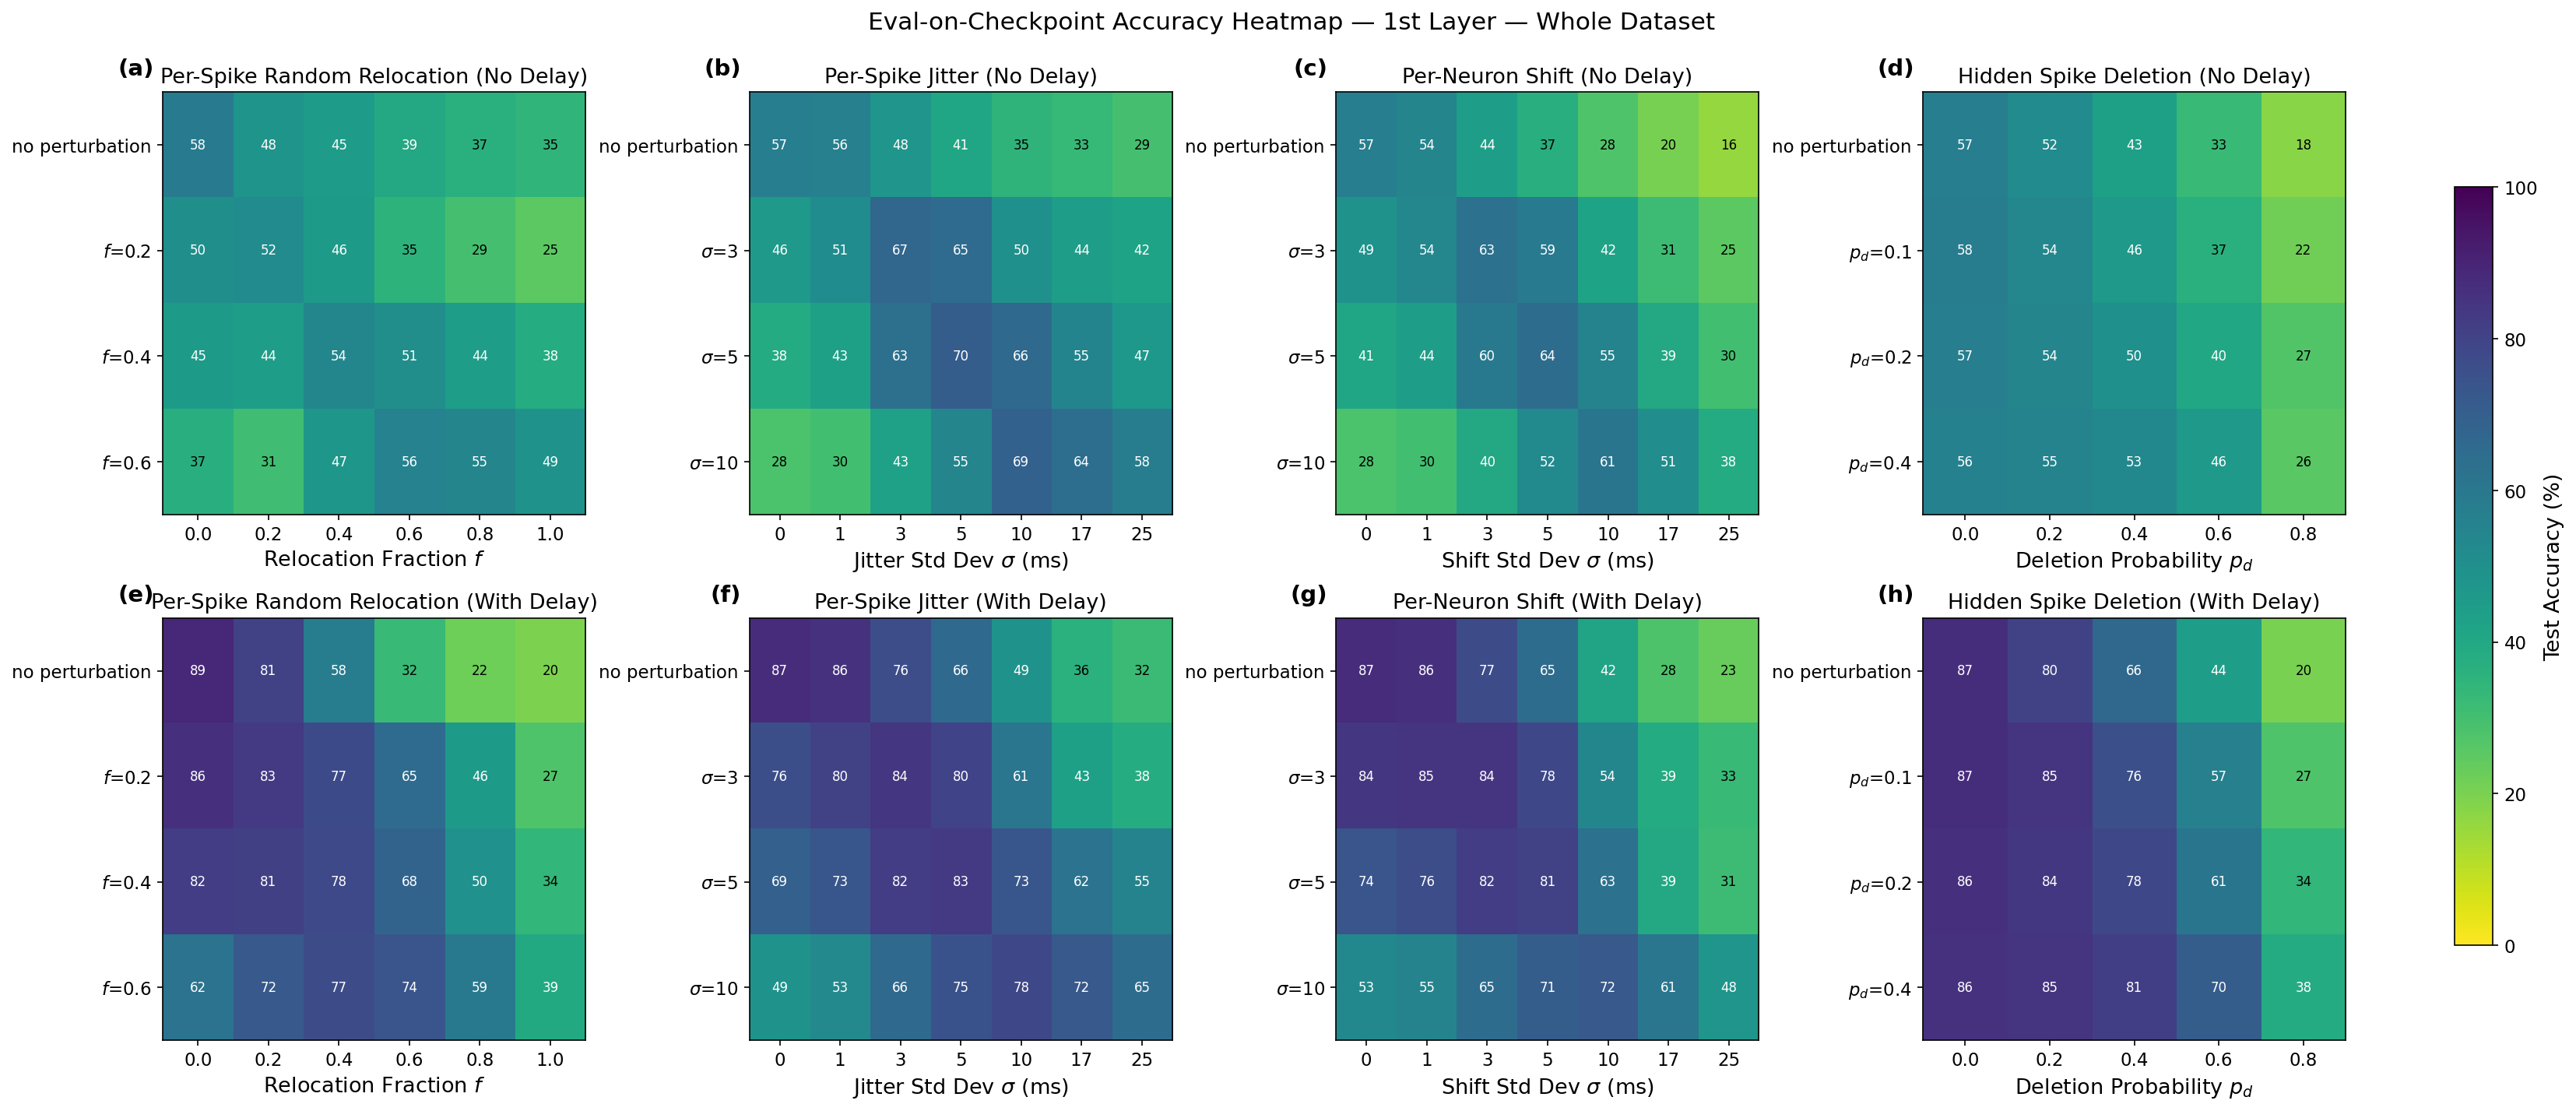

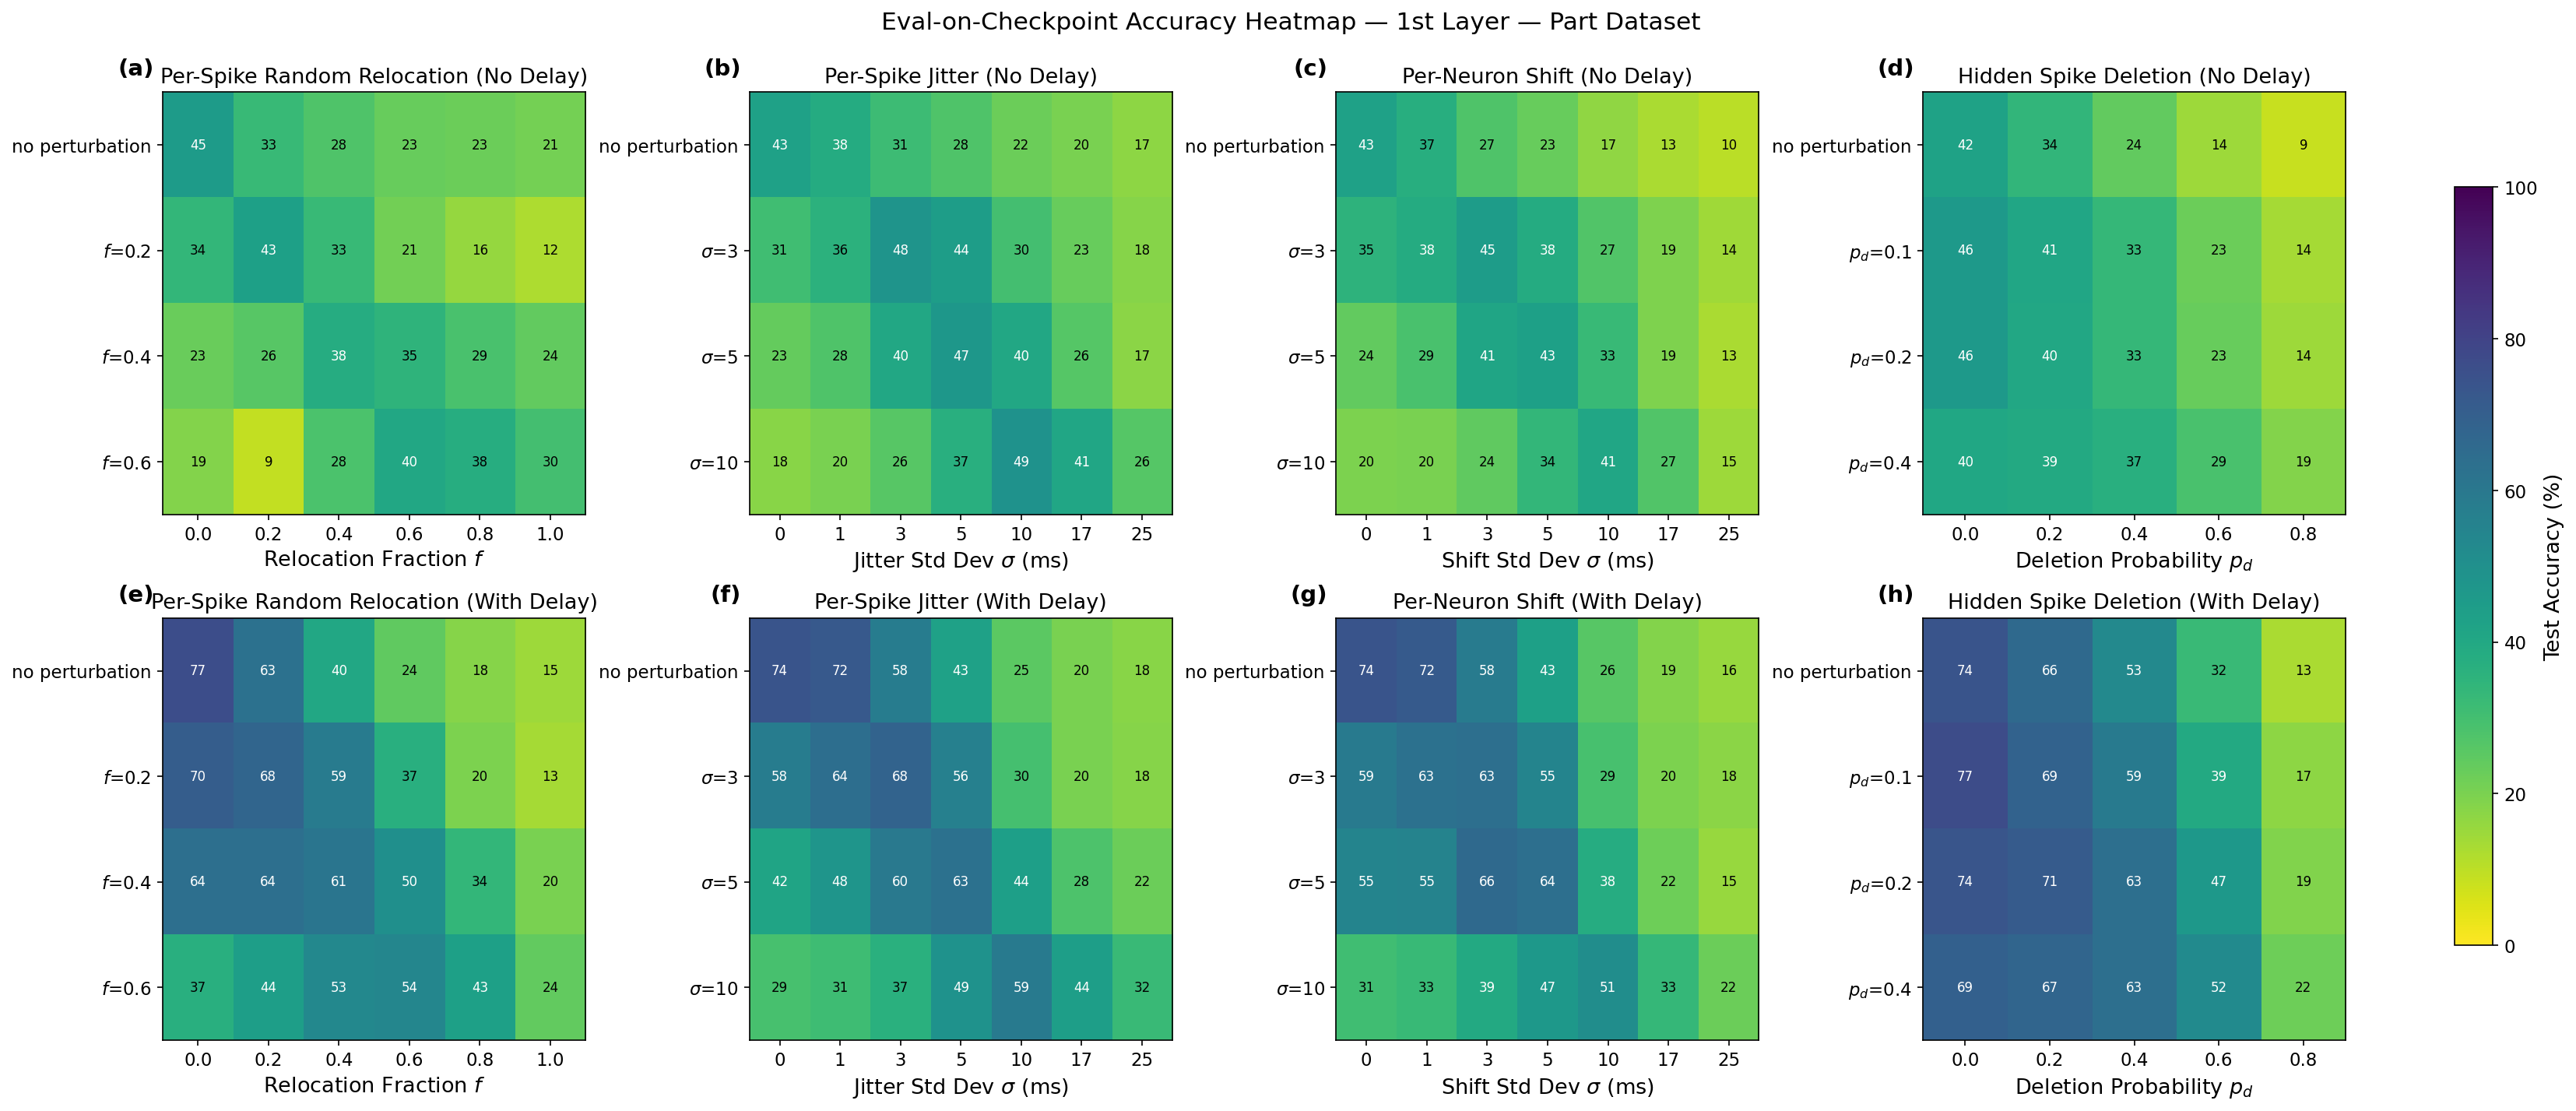

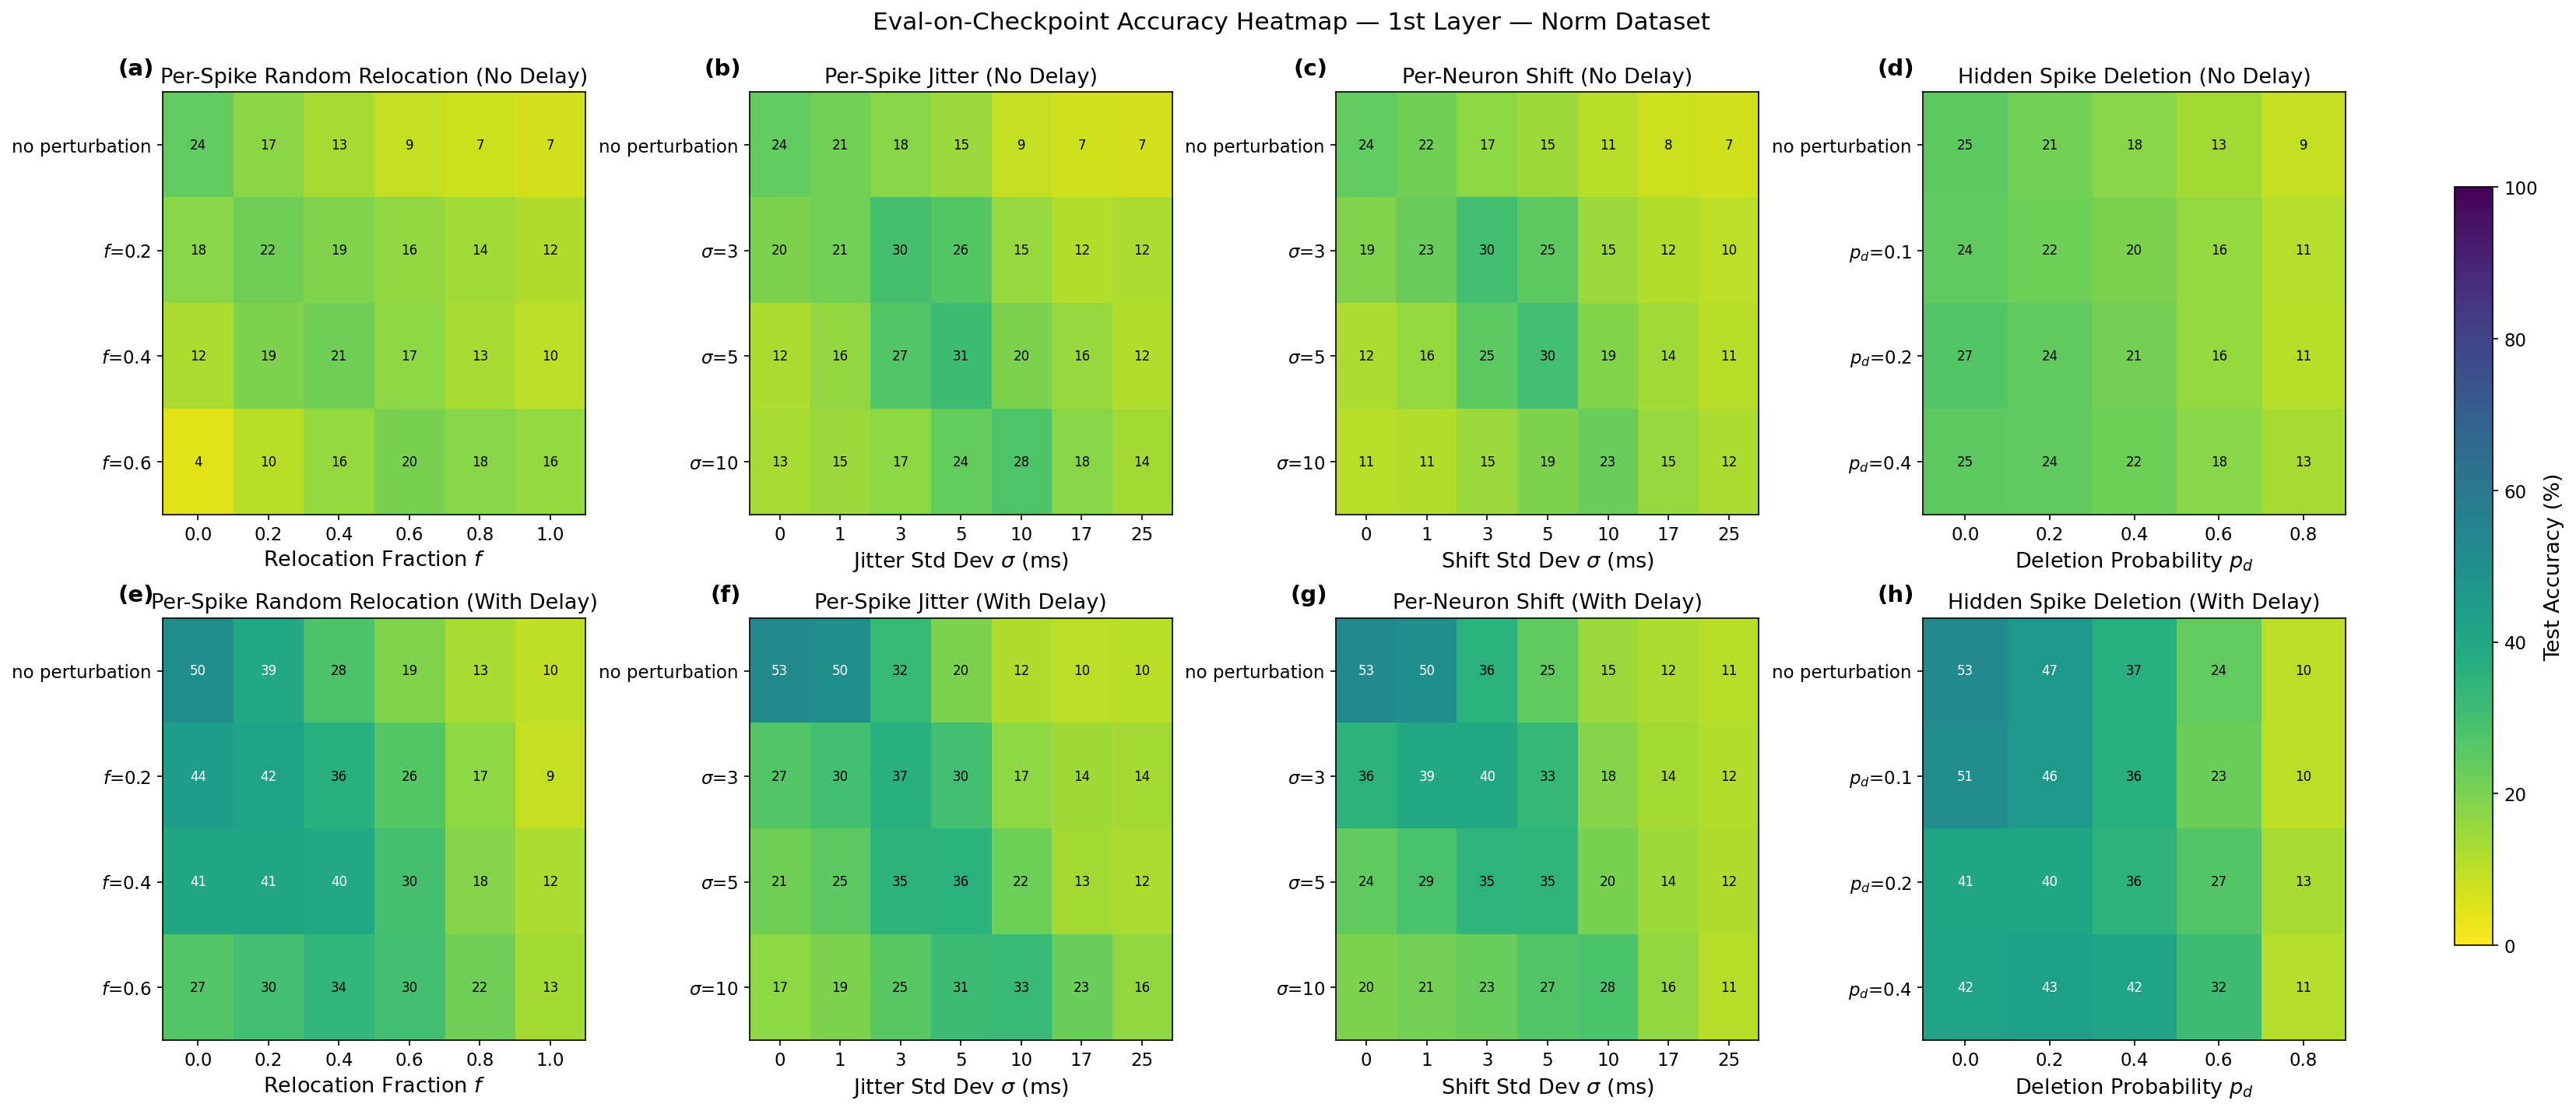

In [4]:
def build_heatmap_matrix(ds, delay_tag, build_config):
    """Build a (train_level x eval_level) accuracy-% matrix for one panel.

    Row 0 is the no-perturbation baseline; the remaining rows are the
    checkpoints trained at each perturbation level, in ascending order.
    Columns follow the evaluation sweep, in ascending order, restricted to the
    levels every row shares — the relocation baseline is swept on a finer grid
    than its checkpoints, so without this the rows would not be alignable.
    """
    cfg = build_config(delay_tag)
    baseline_levels, baseline_means, _ = load_sweep(cfg["baseline_paths"][ds], cfg["key_type"])
    rows = [("no perturbation", baseline_levels, baseline_means)]
    for label, paths in cfg["level_series"]:
        levels, means, _ = load_sweep(paths[ds], cfg["key_type"])
        rows.append((label, levels, means))

    shared = set.intersection(*(set(levels) for _, levels, _ in rows))
    eval_levels = [lvl for lvl in rows[0][1] if lvl in shared]
    train_labels = [label for label, _, _ in rows]
    matrix = np.array([
        [means[levels.index(lvl)] for lvl in eval_levels]
        for _, levels, means in rows
    ])
    return eval_levels, train_labels, matrix


def _heatmap_text_color(value, cmap, norm):
    """Pick black/white text for readable contrast against the cell colour."""
    r, g, b, _ = cmap(norm(value))
    luminance = 0.299 * r + 0.587 * g + 0.114 * b
    return "black" if luminance > 0.5 else "white"


def draw_heatmap_panel(ax, eval_levels, train_labels, matrix, title, xlabel, cmap, norm):
    """Draw one train-level x eval-level accuracy heatmap onto ``ax``."""
    im = ax.imshow(matrix, aspect="auto", cmap=cmap, norm=norm)
    ax.set_xticks(range(len(eval_levels)))
    ax.set_xticklabels([str(v) for v in eval_levels])
    ax.set_yticks(range(len(train_labels)))
    ax.set_yticklabels(train_labels)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            ax.text(j, i, f"{matrix[i, j]:.0f}", ha="center", va="center",
                    fontsize=8, color=_heatmap_text_color(matrix[i, j], cmap, norm))
    return im


HEATMAP_CMAP = plt.get_cmap("viridis_r")
HEATMAP_NORM = mcolors.Normalize(vmin=0, vmax=100)

for ds in EVAL_DATASETS:
    fig, axes = plt.subplots(2, NUM_COLUMNS, figsize=(22, 9), constrained_layout=True)
    im = None
    for row, delay_tag in enumerate(ROW_DELAY_TAGS):
        for col, build_config in enumerate(COLUMN_BUILDERS):
            cfg = build_config(delay_tag)
            eval_levels, train_labels, matrix = build_heatmap_matrix(ds, delay_tag, build_config)
            ax = axes[row, col]
            im = draw_heatmap_panel(
                ax, eval_levels, train_labels, matrix,
                title=f"{cfg['name']} ({DELAY_LABEL[delay_tag]})",
                xlabel=cfg["xlabel"], cmap=HEATMAP_CMAP, norm=HEATMAP_NORM,
            )
            # Right-aligned at the axes' left edge: with four columns the titles
            # are wide enough to reach a left-aligned label and overlap it.
            panel_label = chr(ord("a") + row * NUM_COLUMNS + col)
            ax.text(-0.02, 1.04, f"({panel_label})", transform=ax.transAxes,
                    ha="right", fontsize=14, fontweight="bold")

    fig.suptitle(
        f"Eval-on-Checkpoint Accuracy Heatmap — 1st Layer — {DS_LABEL[ds]} Dataset",
        y=1.04, fontsize=15,
    )
    fig.colorbar(im, ax=axes, shrink=0.8, label="Test Accuracy (%)")
    plt.show()